In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import math
import matplotlib as mpl
import numpy as np
import os
from pandas.tseries.offsets import DateOffset
import matplotlib.gridspec as gridspec
from datetime import datetime
import warnings
from matplotlib.cm import get_cmap

In [2]:
# Inputs
geodata= pd.read_csv('../state_model/GeoData.txt', index_col=0, sep='\t')

fca = pd.read_csv('../hist_data/timeFCON_DD.txt', sep= '\t', skiprows=1, index_col=0)

cilv = pd.read_csv('../hist_data/timeCILV_DD.txt', sep= '\t', skiprows=1, index_col=0)

prec= pd.read_csv('../hist_data/timeCPRC_DD.txt', sep= '\t',skiprows=1, index_col=0)

cout = pd.read_csv('~/research/SMM_Models/hype/model/v10_model/final_model/hds_v3/results/timeCOUT_DD.txt', sep= '\t',skiprows=1, index_col=0)

output_path = "./new_plots/"

# Trim all time-series dataframes to analysis period
date_start = "1985-01-01"
date_end   = "2015-12-31"

gauge_ids = [58290, 58308, 58356, 58363]

In [3]:
# Format data
# Convert columns to string data type
geodata['maindown'] = geodata['maindown'].astype(int)
geodata.index= geodata.index.astype(int)

# Ensure the index is datetime
fca.index = pd.to_datetime(fca.index)
cilv.index = pd.to_datetime(cilv.index)
prec.index = pd.to_datetime(prec.index)
cout.index = pd.to_datetime(cout.index)

# Convert column headers to int
fca.columns = fca.columns.astype(int)
cilv.columns = cilv.columns.astype(int)
prec.columns = prec.columns.astype(int)
cout.columns = cout.columns.astype(int)

# Create a dictionary with subbasin ID and area
subbasin_area = geodata["area"].to_dict()

# Trim dataframes to analysis dates
fca  = fca.loc[date_start:date_end]
cilv = cilv.loc[date_start:date_end]
prec = prec.loc[date_start:date_end]
cout = cout.loc[date_start:date_end]

### Scatter Plot

In [4]:
hype_id_to_location  = {
    '0058328': ('Milk River', 'BCBMO'),
    '0058346': ('Milk River', 'BSCMO'),
    '0058363': ('Milk River', 'BTCIB'),
    '0058425': ('Milk River', 'CLCMO'),
    '0058290': ('Milk River', 'FRRIB'),
    '0058356': ('Milk River', 'LDCIB'),
    '0058408': ('Milk River', 'MRWIB'),
    '0058643': ('Milk River', 'NFKMR'),
    '0058418': ('Milk River', 'PPCMO'),
    '0058398': ('Milk River', 'RKCMO'),
    '0058213': ('St. Mary', 'SMRBB'),
    '0058208': ('St. Mary', 'SMRIB'),
    '0058223': ('St. Mary', 'SWCSB'),
    '0058308': ('Milk River', 'MREIB'),
    '0058242': ('Milk River', 'Outlet')
}

# Streamflow accumulation window for scatter plots (Feb 1 – May 31)
season_start = (2, 1)
season_end   = (5, 31)

# Reference dates for lead time x-axis (weeks from Feb 1)
feb1_ref    = pd.Timestamp(2000, 2, 1)
oct1_ref    = pd.Timestamp(2000, 10, 1)   # Feb 1 + ~6 months
total_weeks = int(round((oct1_ref - feb1_ref).days / 7))  # ≈ 35

# Precompute Feb 1 antecedent dates
start_year = pd.to_datetime(date_start).year
end_year   = pd.to_datetime(date_end).year
feb1_dates = pd.to_datetime([f"{year}-02-01" for year in range(start_year, end_year + 1)])


In [5]:
# Build directed river graph
riv_graph = nx.DiGraph()
for idx, row in geodata.iterrows():
    if row['maindown'] != 0:
        riv_graph.add_edge(idx, row['maindown'])

# --- Results loop: scatter plot data ---
results = {}
for gauge_id in gauge_ids:
    if gauge_id not in riv_graph.nodes:
        print(f"{gauge_id} not found in river graph.")
        results[gauge_id] = None
        continue

    upstream_segments = list(nx.ancestors(riv_graph, gauge_id))
    upstream_segments.append(gauge_id)
    upstream_set = set(upstream_segments)

    cilv_filtered = cilv.loc[:, cilv.columns.isin(upstream_set)].copy()
    cout_filtered = cout[[gauge_id]].copy() if gauge_id in cout.columns else None

    if cout_filtered is None:
        results[gauge_id] = None
        continue

    # --- Seasonal streamflow sum (Feb 1 – May 31) ---
    seasonal_sums = cout_filtered.groupby(cout_filtered.index.year).apply(
        lambda df: df.loc[
            ((df.index.month > season_start[0]) |
             ((df.index.month == season_start[0]) & (df.index.day >= season_start[1]))) &
            ((df.index.month < season_end[0]) |
             ((df.index.month == season_end[0]) & (df.index.day <= season_end[1]))),
            gauge_id
        ].sum()
    )
    seasonal_sums = seasonal_sums.to_frame(name="seasonal_sum")
    seasonal_sums["seasonal_rank"] = seasonal_sums["seasonal_sum"].rank(ascending=True).astype(int)

    # --- Antecedent pothole storage (Feb 1, summed upstream) ---
    cilv_filtered["total_vol"] = cilv_filtered.sum(axis=1)
    antecedent = cilv_filtered.reindex(feb1_dates)[["total_vol"]].rename(
        columns={"total_vol": "antecedent_vol"}
    )
    antecedent["antecedent_rank"] = antecedent["antecedent_vol"].rank(ascending=True).astype(int)
    antecedent.index = antecedent.index.year

    combined = seasonal_sums.merge(antecedent, left_index=True, right_index=True, how="left")
    results[gauge_id] = combined

### Lead Time

In [6]:
# --- Lead time R² loop (Feb 1 to Oct 1, ~35 weeks) ---
r2_results = {gauge_id: [np.nan] * total_weeks for gauge_id in gauge_ids}

for w in range(1, total_weeks + 1):
    loop_end = feb1_ref + pd.DateOffset(weeks=w)
    start_md = (feb1_ref.month, feb1_ref.day)
    end_md   = (loop_end.month, loop_end.day)

    for gauge_id in gauge_ids:
        if gauge_id not in riv_graph.nodes:
            continue

        upstream_segments = list(nx.ancestors(riv_graph, gauge_id))
        upstream_segments.append(gauge_id)
        upstream_set = set(upstream_segments)

        cout_filtered = cout.loc[:, cout.columns.isin([gauge_id])].copy()
        if cout_filtered.empty:
            continue

        cilv_filtered = cilv.loc[:, cilv.columns.isin(upstream_set)].copy()

        seasonal_sums = cout_filtered.groupby(cout_filtered.index.year).apply(
            lambda df: df.loc[
                ((df.index.month > start_md[0]) |
                 ((df.index.month == start_md[0]) & (df.index.day >= start_md[1]))) &
                ((df.index.month < end_md[0]) |
                 ((df.index.month == end_md[0]) & (df.index.day <= end_md[1]))),
                gauge_id
            ].sum()
        )
        seasonal_sums = seasonal_sums.to_frame(name="seasonal_sum")
        seasonal_sums["seasonal_rank"] = seasonal_sums["seasonal_sum"].rank(ascending=True).astype(int)

        cilv_filtered["total_vol"] = cilv_filtered.sum(axis=1)
        antecedent = cilv_filtered.reindex(feb1_dates)[["total_vol"]].rename(
            columns={"total_vol": "antecedent_vol"}
        )
        antecedent["antecedent_rank"] = antecedent["antecedent_vol"].rank(ascending=True).astype(int)
        antecedent.index = antecedent.index.year

        combined_tmp = seasonal_sums.merge(
            antecedent[["antecedent_rank"]], left_index=True, right_index=True, how="left"
        )
        valid_mask = combined_tmp[["antecedent_rank", "seasonal_rank"]].notna().all(axis=1)
        r2_results[gauge_id][w - 1] = (
            r2_score(combined_tmp.loc[valid_mask, "antecedent_rank"],
                     combined_tmp.loc[valid_mask, "seasonal_rank"])
            if valid_mask.sum() > 1 else np.nan
        )

### Combined Plot

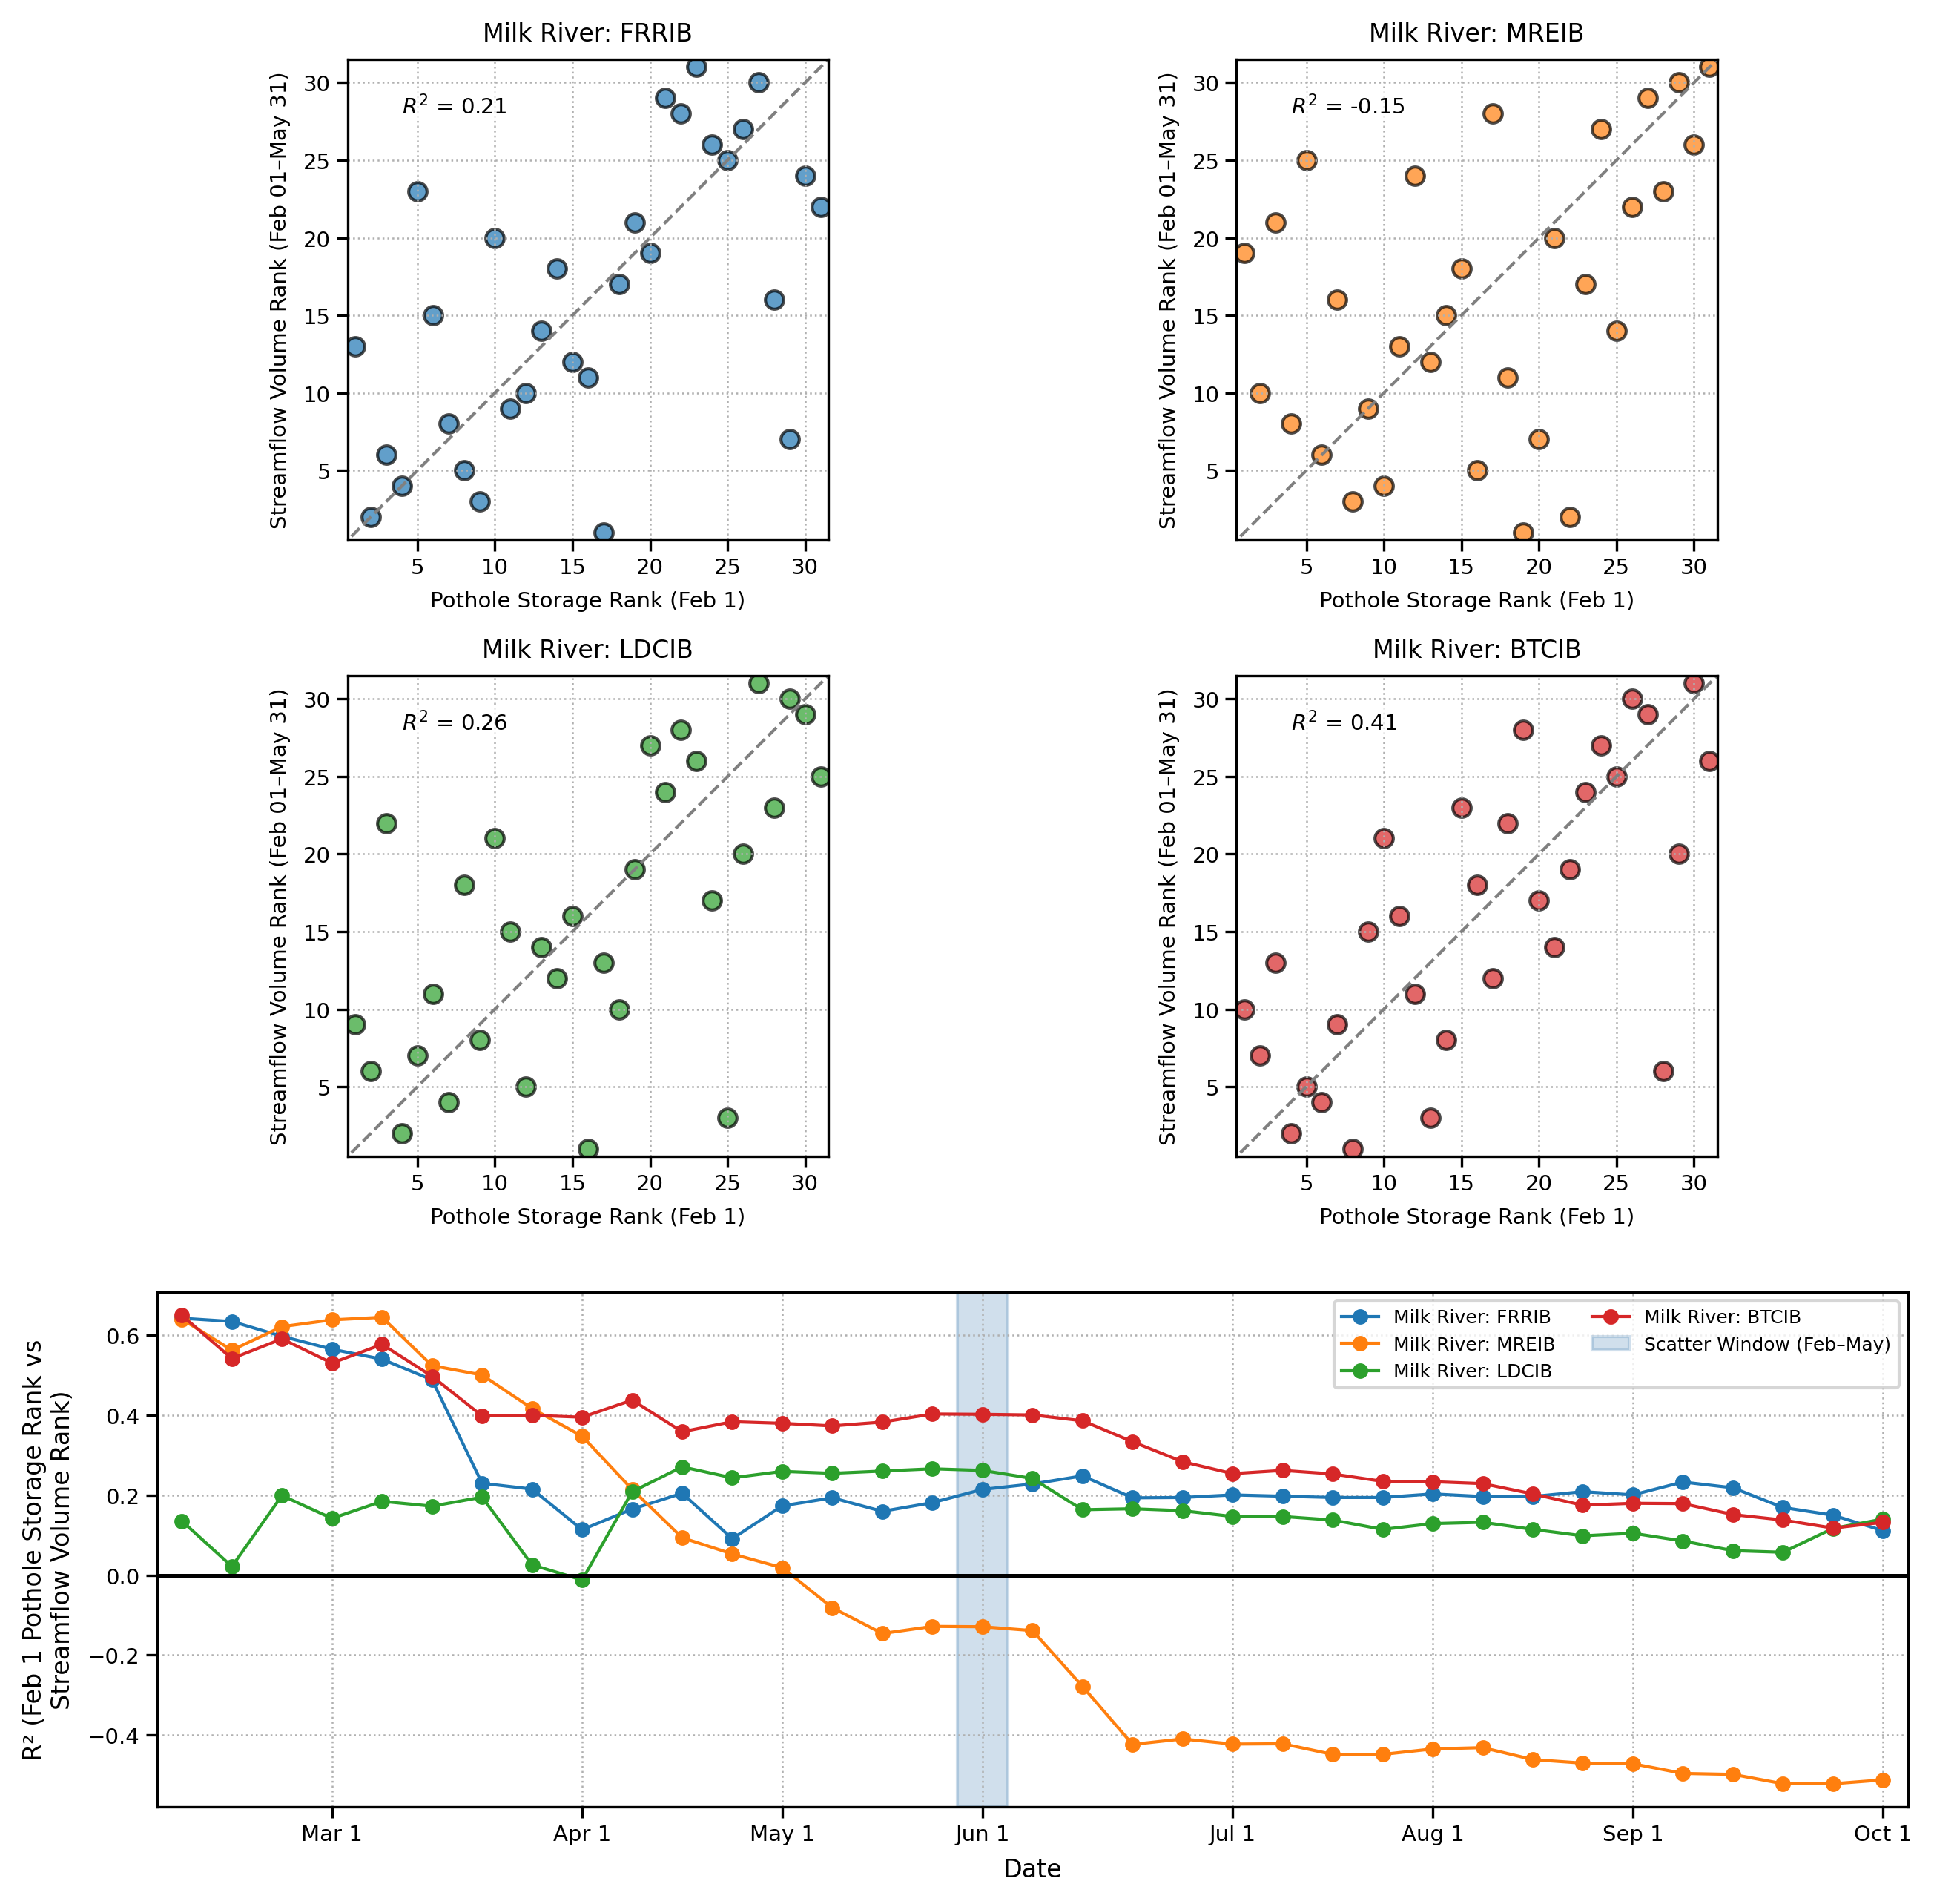

In [8]:
# Shading position: week from Feb 1 where scatter window ends (May 31)
scatter_end_week = int(round((pd.Timestamp(2000, *season_end) - feb1_ref).days / 7))

# --- Matplotlib styling ---
mpl.rcParams.update({
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.dpi': 300,
    'lines.linewidth': 1.2,
    'xtick.major.pad': 2,
    'ytick.major.pad': 2,
    'legend.frameon': False
})

# --- Figure layout (2x2 for 4 gauges) ---
column_width   = 3.5
ncols          = 2
num_gauges     = len(gauge_ids)
nrows          = int(np.ceil(num_gauges / ncols))  # = 2
height_scatter = 2.8
height_r2      = 3.0
fig_width      = column_width * 2.5
fig_height     = nrows * height_scatter + height_r2

fig = plt.figure(figsize=(fig_width, fig_height))
gs  = gridspec.GridSpec(nrows=nrows + 1, ncols=ncols,
                        height_ratios=[height_scatter] * nrows + [height_r2])

cmap   = plt.colormaps['tab10']
colors = [cmap(i % 10) for i in range(num_gauges)]

# Season timestamps for y-axis label
season_start_ts = pd.Timestamp(2000, *season_start)
season_end_ts   = pd.Timestamp(2000, *season_end)

# --- Scatter plots ---
scatter_axes = []
for idx, gauge_id in enumerate(gauge_ids):
    ax = fig.add_subplot(gs[idx // ncols, idx % ncols])
    scatter_axes.append(ax)

    combined = results[gauge_id]
    if combined is None:
        ax.set_visible(False)
        continue

    x = combined["antecedent_rank"]
    y = combined["seasonal_rank"]
    ax.scatter(x, y, color=colors[idx], alpha=0.7, edgecolors='k', s=35)
    max_rank = max(x.max(), y.max())
    ax.plot([0, max_rank + 1], [0, max_rank + 1], '--', color='gray', lw=1)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(0.5, max_rank + 0.5)
    ax.set_ylim(0.5, max_rank + 0.5)
    ax.grid(True, linestyle=':', linewidth=0.6)

    # R² annotation
    valid_mask = combined[["antecedent_rank", "seasonal_rank"]].notna().all(axis=1)
    if valid_mask.sum() > 1:
        r2 = np.round(r2_score(combined.loc[valid_mask, "antecedent_rank"],
                               combined.loc[valid_mask, "seasonal_rank"]), 2)
        x_min, x_max = x.min(), x.max()
        y_min, y_max = y.min(), y.max()
        ax.text(x_min + 0.1 * (x_max - x_min), y_max - 0.1 * (y_max - y_min),
                f'$R^2$ = {r2}', fontsize=7,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    # Title
    gauge_str = str(gauge_id).zfill(7)
    if gauge_str in hype_id_to_location:
        info  = hype_id_to_location[gauge_str]
        title = (f"{info[0]}: {info[1]} ({info[2]} km²)"
                 if len(info) == 3 else f"{info[0]}: {info[1]}")
    else:
        title = f"Gauge {gauge_id}"
    ax.set_title(title, fontsize=8)

    ax.set_xlabel('Pothole Storage Rank (Feb 1)', fontsize=7)
    ax.set_ylabel(
        f"Streamflow Volume Rank "
        f"({season_start_ts.strftime('%b %d')}–{season_end_ts.strftime('%b %d')})",
        fontsize=7
    )

# Hide unused scatter axes
for j in range(num_gauges, nrows * ncols):
    fig.add_subplot(gs[j // ncols, j % ncols]).set_visible(False)

# --- R² vs lead time (bottom panel) ---
r2_ax = fig.add_subplot(gs[-1, :])
for idx, (gauge_id, r2_list) in enumerate(r2_results.items()):
    gauge_str = str(gauge_id).zfill(7)
    if gauge_str in hype_id_to_location:
        info  = hype_id_to_location[gauge_str]
        label = f"{info[0]}: {info[1]}"
    else:
        label = f"Gauge {gauge_id}"
    r2_ax.plot(range(1, len(r2_list) + 1), r2_list,
               marker='o', markersize=4, lw=1, color=colors[idx], label=label)

# Shading: Feb–May scatter window
r2_ax.axvspan(scatter_end_week - 0.5, scatter_end_week + 0.5,
              color='steelblue', alpha=0.25, label='Scatter Window (Feb–May)')
r2_ax.axhline(y=0, color='black', linewidth=1.2, linestyle='-', zorder=2)

# Date labels on x-axis
date_ticks     = [pd.Timestamp(2000, m, 1) for m in range(3, 11)]
tick_positions = [round((t - feb1_ref).days / 7) for t in date_ticks]
tick_labels    = [t.strftime('%b 1') for t in date_ticks]
r2_ax.set_xticks(tick_positions)
r2_ax.set_xticklabels(tick_labels, fontsize=7)

r2_ax.set_xlabel("Date", fontsize=8)
r2_ax.set_ylabel("R² (Feb 1 Pothole Storage Rank vs\nStreamflow Volume Rank)", fontsize=8)
r2_ax.set_xlim(0.5, total_weeks + 0.5)
r2_ax.autoscale(enable=True, axis='y')
r2_ax.grid(True, linestyle=':', linewidth=0.6)
r2_ax.legend(fontsize=6, ncol=2, loc='upper right', frameon=True)

plt.tight_layout()
os.makedirs(output_path, exist_ok=True)
fig.savefig(os.path.join(output_path, 'fig4_antecedent_scatter.png'), dpi=600, bbox_inches='tight')
fig.savefig(os.path.join(output_path, 'fig4_antecedent_scatter.pdf'), format='pdf', bbox_inches='tight')
plt.show()